In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
import seaborn as sns
sns.set_context("paper", font_scale=1.3)
sns.set_style('white')
import warnings
warnings.filterwarnings('ignore')
from time import time
import matplotlib.ticker as tkr
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from sklearn import preprocessing
from statsmodels.tsa.stattools import pacf
%matplotlib inline
import math
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import *
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error


In [3]:
c1=pd.read_csv(r'C:\Users\Goku\Desktop\BBDA\protergia-consumption-analysis\Data_processed\c1_maro.csv', low_memory=False)
c1 = c1.drop_duplicates()
c1 = c1.loc[c1.groupby('time')['kwh'].idxmax()]
c1['time'] = pd.to_datetime(c1['time'], format='%Y%m%d %H:%M:%S')
c1.set_index('time',inplace=True)
c1

,kwh
time,
2018-03-02 00:00:00,272
2018-03-02 00:15:00,261
2018-03-02 00:30:00,277
2018-03-02 00:45:00,270
2018-03-02 01:00:00,263
...,...
2021-07-06 22:45:00,400
2021-07-06 23:00:00,401
2021-07-06 23:15:00,396


In [4]:
df = c1.copy()
df.index = pd.to_datetime(df.index, format='%Y%m%d %H:%M:%S')
df = df.reset_index()

In [5]:
df['year'] = df['time'].apply(lambda x: x.year)
df['quarter'] = df['time'].apply(lambda x: x.quarter)
df['month'] = df['time'].apply(lambda x: x.month)
df['day'] = df['time'].apply(lambda x: x.day)
df['hour'] = df['time'].apply(lambda x: x.hour)

df.sort_values('time', inplace=True, ascending=True)
df = df.reset_index(drop=True)
df["weekday"]=df.apply(lambda row: row["time"].weekday(),axis=1) 
df["weekday"] = (df["weekday"] < 5).astype(int) #1 is weekday, 0 is weekend
print('Number of rows and columns after removing missing values:', df.shape)
print('The time series starts from: ', df.time.min())
print('The time series ends on: ', df.time.max())

Number of rows and columns after removing missing values: (117024, 8)
The time series starts from:  2018-03-02 00:00:00
The time series ends on:  2021-07-06 23:45:00


In [6]:
# df['time'] = pd.to_datetime(df['time'], format='%Y%m%d %H:%M:%S')
# df = df.set_index('time')

In [6]:
df

,time,kwh,year,quarter,month,day,hour,weekday
0,2018-03-02 00:00:00,272,2018,1,3,2,0,1
1,2018-03-02 00:15:00,261,2018,1,3,2,0,1
2,2018-03-02 00:30:00,277,2018,1,3,2,0,1
3,2018-03-02 00:45:00,270,2018,1,3,2,0,1
4,2018-03-02 01:00:00,263,2018,1,3,2,1,1
...,...,...,...,...,...,...,...,...
117019,2021-07-06 22:45:00,400,2021,3,7,6,22,1
117020,2021-07-06 23:00:00,401,2021,3,7,6,23,1
117021,2021-07-06 23:15:00,396,2021,3,7,6,23,1
117022,2021-07-06 23:30:00,399,2021,3,7,6,23,1


In [13]:
dataset = df.kwh.values #numpy.ndarray
dataset = dataset.astype('float32')
dataset = np.reshape(dataset, (-1, 1))
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)
train_size = int(len(dataset) * 0.80)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)
    
look_back = 96
X_train, Y_train = create_dataset(train, look_back)
X_test, Y_test = create_dataset(test, look_back)

# # reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

In [14]:
print(X_train.shape)
train.shape

(93522, 1, 96)


(93619, 1)

In [9]:
length = X_train.shape[0]
# X_test.shape
# len(train)

In [10]:
model5 = Sequential()
model5.add(LSTM(100,return_sequences = True, input_shape=(X_train.shape[1], X_train.shape[2])))
model5.add(Dropout(0.2))
model5.add(LSTM(units = 50, return_sequences = True))
model5.add(Dropout(0.2))
model5.add(LSTM(units = 50, return_sequences = True))
model5.add(Dropout(0.2))
model5.add(LSTM(units = 50))
model5.add(Dropout(0.2))
model5.add(Dense(units = 1))

model5.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['mean_absolute_error'])

history = model5.fit(X_train, Y_train, epochs=50, batch_size=20, validation_data=(X_test, Y_test), 
                    callbacks=[EarlyStopping(monitor='val_loss', patience=25)], verbose=1, shuffle=False)

Epoch 1/50
4677/4677 [==============================] - 91s 12ms/step - loss: 0.0192 - mean_absolute_error: 0.1016 - val_loss: 0.0125 - val_mean_absolute_error: 0.0882
Epoch 2/50
4677/4677 [==============================] - 50s 11ms/step - loss: 0.0055 - mean_absolute_error: 0.0536 - val_loss: 0.0146 - val_mean_absolute_error: 0.0940
Epoch 3/50
4677/4677 [==============================] - 50s 11ms/step - loss: 0.0041 - mean_absolute_error: 0.0454 - val_loss: 0.0054 - val_mean_absolute_error: 0.0545
Epoch 4/50
4677/4677 [==============================] - 54s 11ms/step - loss: 0.0037 - mean_absolute_error: 0.0425 - val_loss: 0.0050 - val_mean_absolute_error: 0.0498
Epoch 5/50
4677/4677 [==============================] - 52s 11ms/step - loss: 0.0032 - mean_absolute_error: 0.0396 - val_loss: 0.0057 - val_mean_absolute_error: 0.0530
Epoch 6/50
4677/4677 [==============================] - 50s 11ms/step - loss: 0.0030 - mean_absolute_error: 0.0386 - val_loss: 0.0044 - val_mean_absolute_error:

In [15]:
print(history.history['mean_absolute_error'][-1])
print(history.history['loss'][-1])  

0.024750463664531708
0.0012500624870881438


In [16]:
train_predict = model5.predict(X_train)
test_predict = model5.predict(X_test)
# invert predictions
train_predict = scaler.inverse_transform(train_predict)
Y_train = scaler.inverse_transform([Y_train])
test_predict = scaler.inverse_transform(test_predict)
Y_test = scaler.inverse_transform([Y_test])
print('Train Mean Absolute Error:', mean_absolute_error(Y_train[0], train_predict[:,0]))
print('Train Root Mean Squared Error:',np.sqrt(mean_squared_error(Y_train[0], train_predict[:,0])))
print('Test Mean Absolute Error:', mean_absolute_error(Y_test[0], test_predict[:,0]))
print('Test Root Mean Squared Error:',np.sqrt(mean_squared_error(Y_test[0], test_predict[:,0])))

Train Mean Absolute Error: 15.387945830698428
Train Root Mean Squared Error: 21.553599344542064
Test Mean Absolute Error: 13.962301118524405
Test Root Mean Squared Error: 20.763682357255863


In [17]:
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred)) /np.mean( y_true)) * 100
print(mean_absolute_percentage_error(Y_train[0],train_predict[:,0]))
mean_absolute_percentage_error(Y_test[0],test_predict[:,0])

5.413256260488744


5.018570425970408

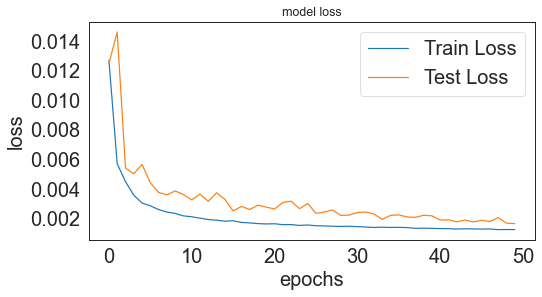

In [26]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('model loss')
plt.ylabel('loss', size=20)
plt.xlabel('epochs', size=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(loc='upper right',fontsize=20)
plt.show();

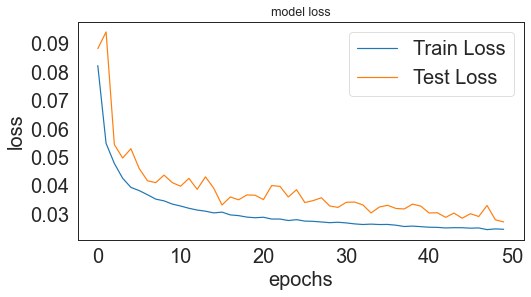

In [27]:
plt.figure(figsize=(8,4))
plt.plot(history.history['mean_absolute_error'], label='Train Loss')
plt.plot(history.history['val_mean_absolute_error'], label='Test Loss')
plt.title('model loss')
plt.ylabel('loss', size=20)
plt.xlabel('epochs', size=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(loc='upper right',fontsize=20)
plt.show();

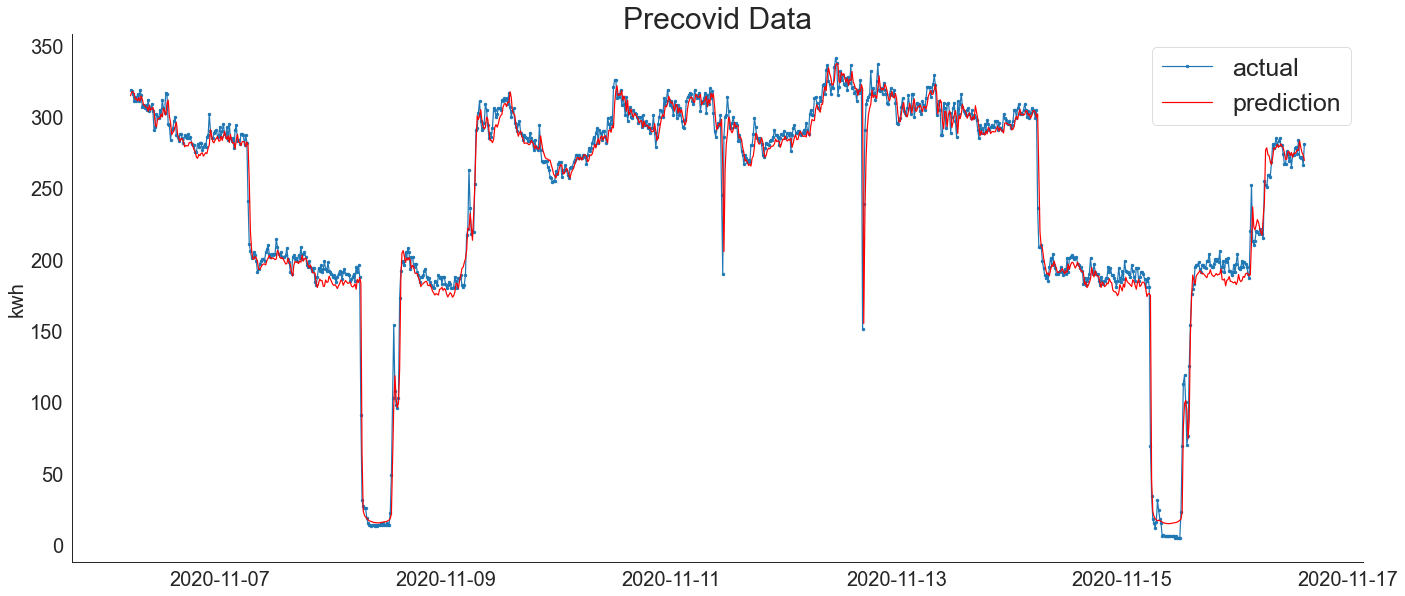

In [21]:
aa=[x for x in range(len(Y_test[0]))]
plt.figure(figsize=(20,8))
plt.plot(df['time'][-len(Y_test[0]):][:1000], Y_test[0][:][:1000], marker='.', label="actual")
plt.plot(df['time'][-len(Y_test[0]):][:1000], test_predict[:,0][:][:1000], 'r', label="prediction")

# MAE = mean_absolute_error(Y_test[0], test_predict[:,0])
# RMSE = np.sqrt(mean_squared_error(Y_test[0], test_predict[:,0]))

# m_a_e = history.history['mean_absolute_error'][-1]
# m_s_e =history.history['loss'][-1]

# textstr1 = "MAE = " + "{:.3f}".format(MAE) + "  RMSE = " + "{:.3f}".format(RMSE)
# textstr2 = "mae = " + "{:.3f}%".format(100*m_a_e) + "  rmse = " + "{:.3f}%".format(100*m_s_e)

# # place a text box in upper left in axes coords
# plt.annotate(textstr1, xy=(0.77, 0.05), xycoords='axes fraction')
# plt.annotate(textstr2, xy=(0.77, 0.02), xycoords='axes fraction')

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tick_params(left=False, labelleft=True) #remove ticks
plt.tight_layout()
sns.despine(top=True)
plt.subplots_adjust(left=0.07)
plt.ylabel('kwh', size=20)
plt.title('Data',fontsize=30)
# plt.xlabel('Time step', size=15)
plt.legend(fontsize=25)
plt.show();

In [64]:
df['time'][-len(Y_test[0]):]

61844   2020-10-28 05:00:00
61845   2020-10-28 05:15:00
61846   2020-10-28 05:30:00
61847   2020-10-28 05:45:00
61848   2020-10-28 06:00:00
                ...        
77179   2021-04-05 22:45:00
77180   2021-04-05 23:00:00
77181   2021-04-05 23:15:00
77182   2021-04-05 23:30:00
77183   2021-04-05 23:45:00
Name: time, Length: 15340, dtype: datetime64[ns]

In [65]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x= df['time'][-len(Y_test[0]):], y=Y_test[0][:], name='Real'))
fig.add_trace(go.Scatter(x= df['time'][-len(Y_test[0]):], y=test_predict[:,0][:], name='Preds'))
fig.show()

In [66]:
datata= pd.DataFrame({'time': df['time'][-len(Y_test[0]):][:], 'kwh': Y_test[0][:], 'predictions':test_predict[:,0][:]})

In [67]:
fig = go.Figure()
fig.add_trace(go.Scatter(x= datata['time'], y=datata['kwh'], name='Real'))
fig.add_trace(go.Scatter(x= datata['time'], y=datata['predictions'], name='Preds'))
fig.show()

In [68]:
datata.to_csv('alltime4.csv')

In [18]:
n_future=96 #Redefining n_future to extend prediction dates beyond original n_future dates...
forecast_period_dates = pd.date_range(list(df['time'][:length])[-1], periods=n_future, freq='15min').tolist()

In [19]:
list(df['time'][:length])[-1]

Timestamp('2020-11-04 04:15:00')

In [20]:
forecast_try = model5.predict(X_train[-n_future:]) #forecast 

In [21]:
forecast_copies = np.repeat(forecast_try,1, axis= -1 )
y_pred_future = scaler.inverse_transform(forecast_copies)[:,0]

In [22]:
forecast_dates = []
for time_i in forecast_period_dates:
    forecast_dates.append(time_i)
    
df_forecast = pd.DataFrame({'time':np.array(forecast_dates), 'kwh':y_pred_future})
df_forecast['time']=pd.to_datetime(df_forecast['time'])

In [26]:
original = df[['time', 'kwh']]
original['time']=pd.to_datetime(original['time'])
original_test = original[length-1:][:96]
original = original.loc[original['time'] <=list(df['time'][:length])[-1]][-200:]

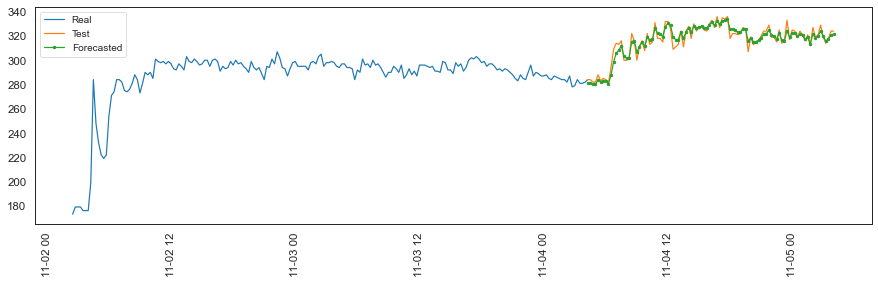

In [27]:
# sns.lineplot(original['time'], original['kwh'])
# sns.lineplot(df_forecast['time'], df_forecast['kwh'])

plt.figure(figsize=(15,4))
plt.plot(original['time'], original['kwh'], label ='Real')
plt.plot(original_test['time'],original_test['kwh'], label='Test')
plt.plot(df_forecast['time'], df_forecast['kwh'],marker='.', label = 'Forecasted')
plt.xticks(rotation=90)
plt.legend(fontsize=10)
plt.show()

In [7]:
dataset = df.kwh.values #numpy.ndarray
dataset = dataset.astype('float32')
dataset = np.reshape(dataset, (-1, 1))
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)
# train_size = int(len(dataset) * 0.80)
# test_size = len(dataset) - train_size
train = dataset[0:,:]

def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)
    
look_back = 96
X_train, Y_train = create_dataset(train, look_back)

# # reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))


In [8]:
print(X_train.shape)
train.shape

(116927, 1, 96)


(117024, 1)

In [9]:
length = X_train.shape[0]
# X_test.shape
# len(train)

In [10]:
model5 = Sequential()
model5.add(LSTM(100,return_sequences = True, input_shape=(X_train.shape[1], X_train.shape[2])))
# model5.add(Dropout(0.2))
model5.add(LSTM(units = 50, return_sequences = True))
# model5.add(Dropout(0.2))
model5.add(LSTM(units = 50, return_sequences = True))
# model5.add(Dropout(0.2))
model5.add(LSTM(units = 50))
# model5.add(Dropout(0.2))
model5.add(Dense(units = 1))

model5.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['mean_absolute_error'])

history = model5.fit(X_train, Y_train, epochs=50, batch_size=20, verbose=1, shuffle=False)

Epoch 1/50
5847/5847 [==============================] - 67s 7ms/step - loss: 0.0149 - mean_absolute_error: 0.0851
Epoch 2/50
5847/5847 [==============================] - 42s 7ms/step - loss: 0.0033 - mean_absolute_error: 0.0397
Epoch 3/50
5847/5847 [==============================] - 47s 8ms/step - loss: 0.0026 - mean_absolute_error: 0.0352
Epoch 4/50
5847/5847 [==============================] - 47s 8ms/step - loss: 0.0023 - mean_absolute_error: 0.0331
Epoch 5/50
5847/5847 [==============================] - 52s 9ms/step - loss: 0.0019 - mean_absolute_error: 0.0302
Epoch 6/50
5847/5847 [==============================] - 52s 9ms/step - loss: 0.0017 - mean_absolute_error: 0.0286
Epoch 7/50
5847/5847 [==============================] - 52s 9ms/step - loss: 0.0017 - mean_absolute_error: 0.0281: 
Epoch 8/50
5847/5847 [==============================] - 52s 9ms/step - loss: 0.0015 - mean_absolute_error: 0.0262
Epoch 9/50
5847/5847 [==============================] - 55s 9ms/step - loss: 0.0014 - 

In [11]:
n_future=96 #Redefining n_future to extend prediction dates beyond original n_future dates...
forecast_period_dates = pd.date_range(list(df['time'])[-1], periods=n_future, freq='15min').tolist()

In [12]:
list(df['time'])[-1]


Timestamp('2021-07-06 23:45:00')

In [13]:
forecast_try = model5.predict(X_train[-n_future:]) #forecast 

In [14]:
forecast_copies = np.repeat(forecast_try,1, axis= -1 )
y_pred_future = scaler.inverse_transform(forecast_copies)[:,0]

In [15]:
forecast_dates = []
for time_i in forecast_period_dates:
    forecast_dates.append(time_i)
    
df_forecast = pd.DataFrame({'time':np.array(forecast_dates), 'kwh':y_pred_future})
df_forecast['time']=pd.to_datetime(df_forecast['time'])

In [16]:
original = df[['time', 'kwh']]
original['time']=pd.to_datetime(original['time'])
original = original.loc[original['time'] <= list(df['time'])[-1]][-200:]

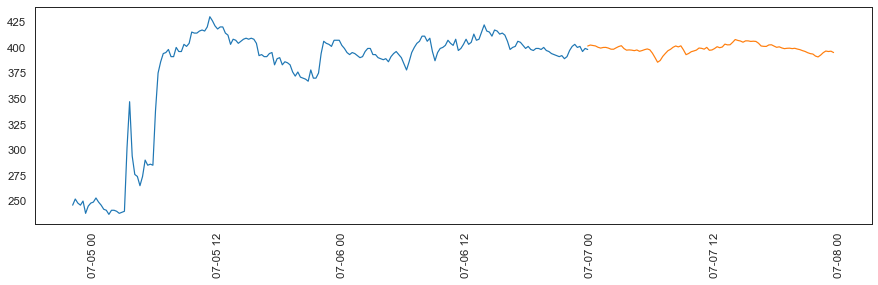

In [17]:
# sns.lineplot(original['time'], original['kwh'])
# sns.lineplot(df_forecast['time'], df_forecast['kwh'])

plt.figure(figsize=(15,4))
plt.plot(original['time'], original['kwh'])
plt.plot(df_forecast['time'], df_forecast['kwh'])
plt.xticks(rotation=90)
plt.show()